In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Hot Hand Analysis

Goal: Test whether previous shot outcomes affect the probability of making the next shot.

Approach:
- Treat shot outcomes as a time series
- Use autocorrelation (ACF)
- Fit a logistic autoregressive model

## Player Shot Data Preparation
This section loads the selected season’s play-by-play data, filters it to a specific player’s shot attempts, and cleans/sorts the data into the correct chronological order within each game. It then creates a binary “made” variable, removes games with too few shots, and returns a structured dataset ready for analysis (e.g., streaks, hot hand modeling).

In [2]:
# Configuration
SEASON = 2006
DATA_DIR = "pbp"

PLAYER_NAME = "K. Bryant"
PLAYER_ID = 977

SHOT_TYPES = ["Made Shot", "Missed Shot"]
MIN_SHOTS_PER_GAME = 10

In [3]:
def get_data_path(season, data_dir="pbp"):
    return f"{data_dir}/pbp{season}.csv"

def load_and_prepare_player_data(
    season,
    data_dir="pbp",
    player_name=None,
    player_id=None,
    shot_types=("Made Shot", "Missed Shot"),
    min_shots_per_game=1
):
    data_path = get_data_path(season, data_dir)
    df = pd.read_csv(data_path).copy()

    # clean text columns
    for col in ["player", "type", "result", "clock"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # keep only shot attempts
    df = df[df["type"].isin(shot_types)].copy()

    # filter by player
    if player_id is not None:
        df = df[df["playerid"] == player_id].copy()
    elif player_name is not None:
        df = df[df["player"] == player_name].copy()
    else:
        raise ValueError("Provide either player_name or player_id.")

    if df.empty:
        raise ValueError(f"No rows found for player in season {season}.")

    # binary shot outcome
    df["made"] = (df["result"] == "Made").astype(int)

    # convert clock to seconds remaining
    clock_parts = df["clock"].str.extract(r"PT(\d+)M([\d\.]+)S")
    df["clock_sec"] = clock_parts[0].astype(float) * 60 + clock_parts[1].astype(float)

    # sort within each game
    df = df.sort_values(
        ["gameid", "period", "clock_sec"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    # minimum shots per game
    shots_per_game = df.groupby("gameid").size()
    valid_games = shots_per_game[shots_per_game >= min_shots_per_game].index
    df = df[df["gameid"].isin(valid_games)].copy()

    # add season column if needed
    df["season"] = season

    return df

In [4]:
df = load_and_prepare_player_data(
    season=SEASON,
    data_dir=DATA_DIR,
    player_name=PLAYER_NAME,
    player_id=PLAYER_ID,
    shot_types=SHOT_TYPES,
    min_shots_per_game=MIN_SHOTS_PER_GAME
)

made_per_game = df.groupby("gameid")["made"].sum()

print("Season:", SEASON)
print("Player:", df["player"].iloc[0])
print("Player ID:", df["playerid"].iloc[0])
print("Rows:", len(df))
print("Games:", df["gameid"].nunique())
print("Most Made Shots in a Game:", int(made_per_game.max()))
df.head()

Season: 2006
Player: K. Bryant
Player ID: 977
Rows: 2318
Games: 87
Most Made Shots in a Game: 28


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season,made,clock_sec
0,20500016,1,PT10M43.00S,0.0,0.0,LAL,977,K. Bryant,Missed Shot,Driving Layup Shot,Missed,0,0,0,MISS Bryant Driving Layup,2006,0,643.0
1,20500016,1,PT09M56.00S,6.0,5.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,79,199,21,Bryant 21' Jump Shot (2 PTS) (Parker 1 AST),2006,1,596.0
2,20500016,1,PT08M19.00S,8.0,10.0,LAL,977,K. Bryant,Made Shot,Turnaround Jump Shot,Made,-104,76,13,Bryant 13' Turnaround Jump Shot (4 PTS),2006,1,499.0
3,20500016,1,PT07M32.00S,10.0,12.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,151,61,16,Bryant 16' Jump Shot (6 PTS) (George 1 AST),2006,1,452.0
4,20500016,1,PT07M02.00S,12.0,14.0,LAL,977,K. Bryant,Made Shot,Reverse Layup Shot,Made,0,0,0,Bryant Reverse Layup (8 PTS) (Parker 2 AST),2006,1,422.0


In [23]:
def find_players(season, search_text, data_dir="pbp"):
    data_path = get_data_path(season, data_dir)
    df = pd.read_csv(data_path, usecols=["playerid", "player"]).drop_duplicates()
    df["player"] = df["player"].astype(str).str.strip()
    result = df[df["player"].str.contains(search_text, case=False, na=False)]
    return result.sort_values("player").reset_index(drop=True)

find_players(SEASON, "jack")

,playerid,player
0,1517,B. Jackson
1,101127,J. Jack
2,754,J. Jackson
3,1983,J. Jackson
4,2739,L. Jackson
5,1531,M. Jackson
6,1536,S. Jackson


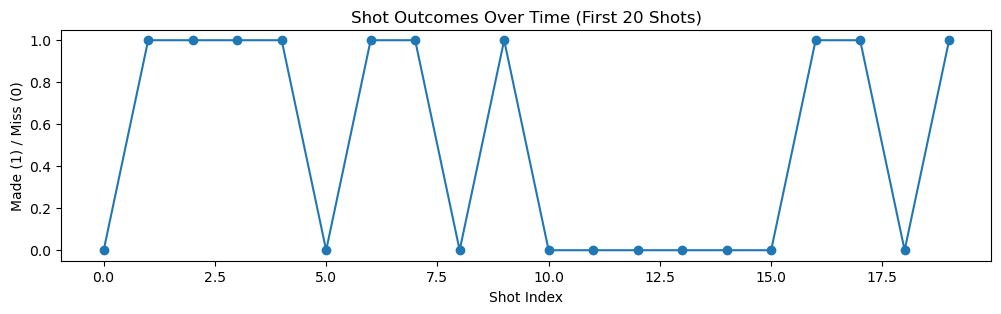

In [8]:
plt.figure(figsize=(12, 3))
plt.plot(df["made"].values[:20], marker='o', linestyle='-')
plt.title("Shot Outcomes Over Time (First 20 Shots)")
plt.xlabel("Shot Index")
plt.ylabel("Made (1) / Miss (0)")
plt.show()

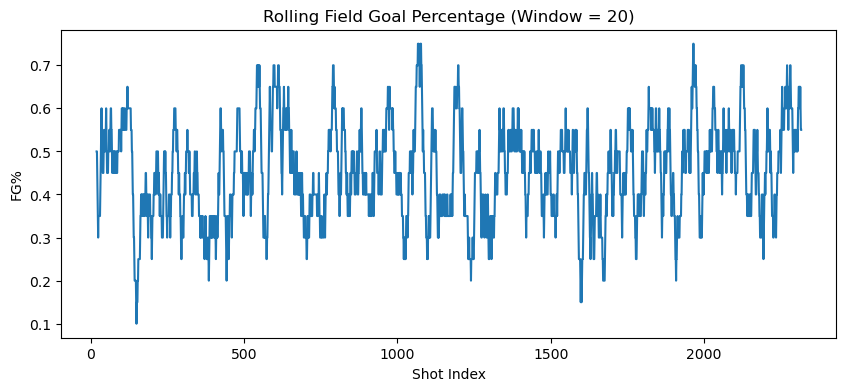

In [9]:
df["rolling_fg"] = df["made"].rolling(window=20).mean()

plt.figure(figsize=(10, 4))
plt.plot(df["rolling_fg"])
plt.title("Rolling Field Goal Percentage (Window = 20)")
plt.xlabel("Shot Index")
plt.ylabel("FG%")
plt.show()

## Basic Summary

The mean represents shooting percentage.

If shots are independent, we should not see strong dependence across time.

In [10]:
print("Mean:", df["made"].mean())
print("Variance:", df["made"].var())

Mean: 0.45297670405522
Variance: 0.24789575344930312


## Feature Engineering

We create lag variables to capture previous shot outcomes within each game.

These will be used to test whether recent shots influence future performance.

In [11]:
# Create lagged shot outcomes within each game
for lag in range(1, 4):
    df[f"lag{lag}"] = df.groupby("gameid")["made"].shift(lag)

# Drop rows where lags are missing
model_df = df.dropna(subset=["lag1", "lag2", "lag3"]).copy()

# Convert to int
for lag in range(1, 4):
    model_df[f"lag{lag}"] = model_df[f"lag{lag}"].astype(int)

print("Modeling rows:", len(model_df))
model_df[["gameid", "made", "lag1", "lag2", "lag3"]].head()

Modeling rows: 2057


,gameid,made,lag1,lag2,lag3
3,20500016,1,1,1,0
4,20500016,1,1,1,1
5,20500016,0,1,1,1
6,20500016,1,0,1,1
7,20500016,1,1,0,1


made         0         1
lag1                    
0     0.539497  0.460503
1     0.565217  0.434783


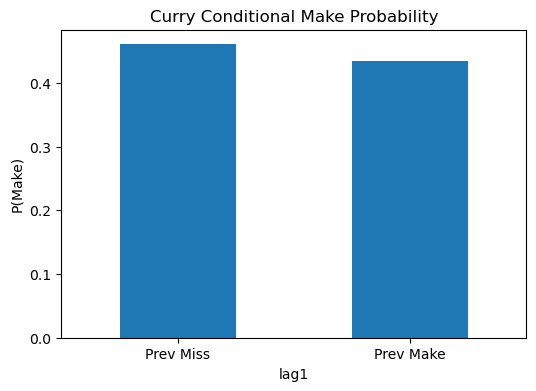

In [12]:
# Conditional probabilities
hot_hand_table = pd.crosstab(model_df["lag1"], model_df["made"], normalize="index")
print(hot_hand_table)

# Plot
probs = hot_hand_table[1]

plt.figure(figsize=(6, 4))
probs.plot(kind="bar")
plt.xticks([0, 1], ["Prev Miss", "Prev Make"], rotation=0)
plt.ylabel("P(Make)")
plt.title("Conditional Make Probability")
plt.show()

While the ACF analysis suggests little linear dependence in shot outcomes, it may fail to detect subtle probabilistic effects due to the binary nature of the data. 

To more directly test for a hot hand effect, we estimate a logistic autoregressive model, where the probability of making a shot depends on recent shot outcomes within the same game.

## Logistic Autoregressive Model

We model the probability of making a shot as a function of recent shot history.

This allows us to directly test for a hot hand effect.

In [13]:
# Logistic autoregressive model
logit_model = smf.glm(
    formula="made ~ lag1 + lag2 + lag3",
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": model_df["gameid"]})

print(logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   made   No. Observations:                 2057
Model:                            GLM   Df Residuals:                     2053
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1411.6
Date:                Wed, 08 Apr 2026   Deviance:                       2823.2
Time:                        18:48:51   Pearson chi2:                 2.06e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003276
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2082      0.078     -2.679      0.0

## Interpretation

- lag1: effect of previous shot
- lag2, lag3: longer memory effects

If coefficients are:
- Positive = hot hand
- Near zero = independence
- Negative = regression to the mean

In this case:
- lag1 is slightly negative and not significant
- lag2 is near zero
- lag3 is slightly negative

This suggests little to no evidence of a hot hand effect.

In [14]:
# Predictions
model_df["pred_prob"] = logit_model.predict(model_df)

model_df[["made", "lag1", "lag2", "lag3", "pred_prob"]].head()

,made,lag1,lag2,lag3,pred_prob
3,1,1,1,0,0.470378
4,1,1,1,1,0.448887
5,0,1,1,1,0.448887
6,1,0,1,1,0.472642
7,1,1,0,1,0.403622


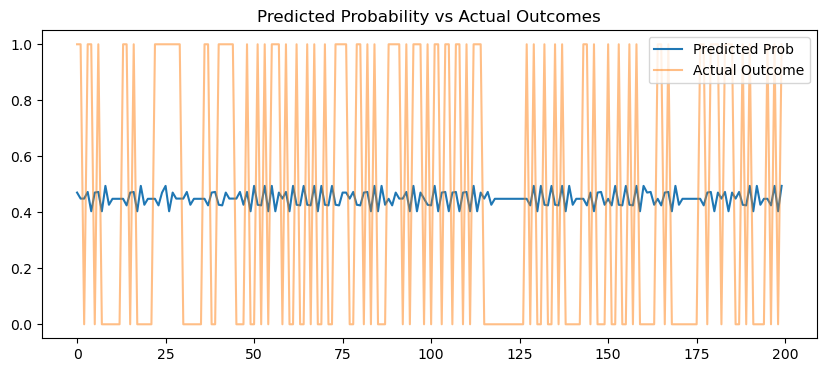

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(model_df["pred_prob"].values[:200], label="Predicted Prob")
plt.plot(model_df["made"].values[:200], alpha=0.5, label="Actual Outcome")
plt.legend()
plt.title("Predicted Probability vs Actual Outcomes")
plt.show()

## Autocorrelation (ACF)

We test whether shot outcomes are linearly dependent on previous shots.

If a hot hand exists, we expect positive autocorrelation at small lags.

<Figure size 800x400 with 0 Axes>

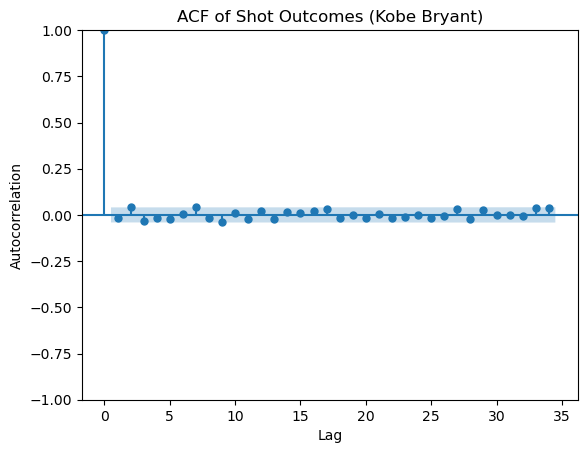

In [16]:
# ACF of shot outcomes (all games, ordered correctly)
series = model_df["made"]

plt.figure(figsize=(8, 4))
plot_acf(df["made"])
plt.title("ACF of Shot Outcomes (Kobe Bryant)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

ACF may fail to detect dependence because the data is binary.

We therefore use a logistic autoregressive model next.

## Partial Autocorrelation (PACF)

PACF helps isolate the direct effect of each lag.

<Figure size 800x400 with 0 Axes>

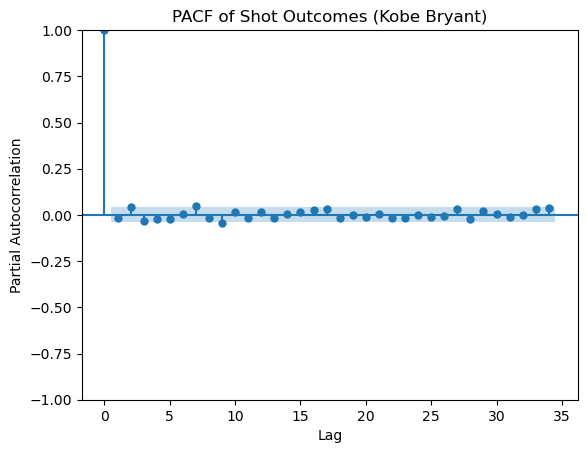

In [17]:
plt.figure(figsize=(8, 4))
plot_pacf(df["made"])
plt.title("PACF of Shot Outcomes (Kobe Bryant)")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

In [18]:
# Convert to class predictions
model_df["pred_class"] = (model_df["pred_prob"] >= 0.5).astype(int)

# Metrics
auc = roc_auc_score(model_df["made"], model_df["pred_prob"])
ll = log_loss(model_df["made"], model_df["pred_prob"])
acc = accuracy_score(model_df["made"], model_df["pred_class"])

print(f"ROC-AUC: {auc:.4f}")
print(f"Log Loss: {ll:.4f}")
print(f"Accuracy: {acc:.4f}")

ROC-AUC: 0.5329
Log Loss: 0.6862
Accuracy: 0.5513


In [19]:
print("Lag 1 correlation:", np.corrcoef(df["made"][:-1], df["made"][1:])[0,1])

Lag 1 correlation: -0.01886345698500408


In [20]:
# plot diagnostics (residuals) ?
# mean absolute error (mae) ?
# root mean squared error (rmse) ?